In [4]:
# This is a small model of a LIF neuron

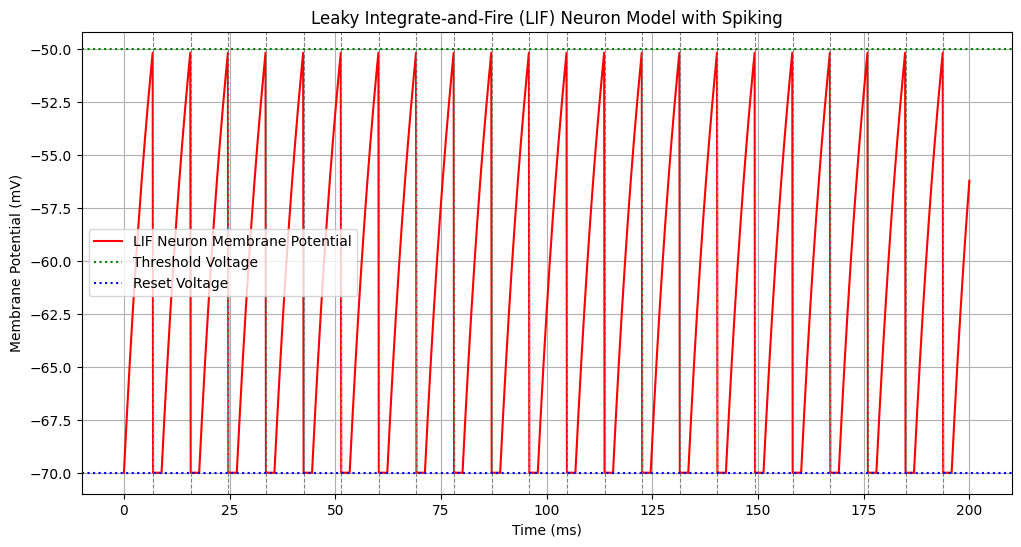

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, refractory_period_steps, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], *args)
            u[i+1] = u[i] + h * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 10.0     # Membrane time constant (ms)
R = 10.0     # Membrane resistance (MOhms)
I = 3.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)
refractory_period_steps = int(refractory_period / h_val)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(
    dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, refractory_period_steps, k, a, R, I
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

This is an example of a LIF neuron model, based upon the concept of the neuronal membrane being modeled as a circuit with two paths for current flow across the potential difference of the cell membrane.

one path (Path 1) is through a capacitor C, exemplifying the lipid bilayer chemistry of the neuron membrane. Another path (Path 2) is through a resistance and a battery in series, representing the effect of ion channels and pumps in the cell membrane.

Another condition is also the firing time condition, which signifies the neuron's primary role to 'fire' a spike just as the potential crosses a certain limit, after which the membrane returns to resting potential.

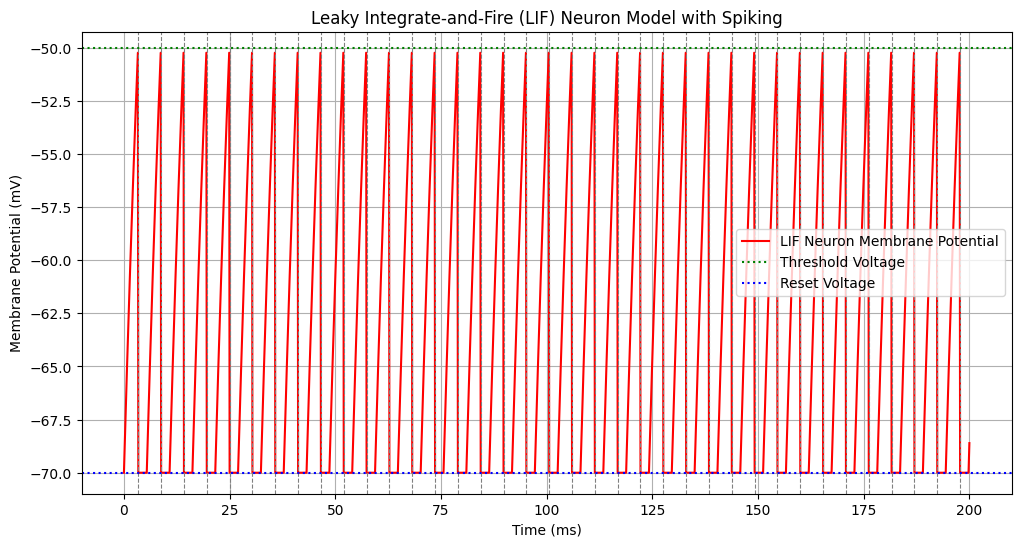

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, refractory_period_steps, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], *args)
            u[i+1] = u[i] + h * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 10.0     # Membrane time constant (ms)
R = 30.0     # Membrane resistance (MOhms)
I = 2.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)
refractory_period_steps = int(refractory_period / h_val)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(
    dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, refractory_period_steps, k, a, R, I
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

This is the same model with a different Resistance of 100 mOhms, from the previous 10 mOhms. The change, exemplified by the increased number of peaks and decreased interpeak interval, implies a decrease in current flow through the membrane through path 2.

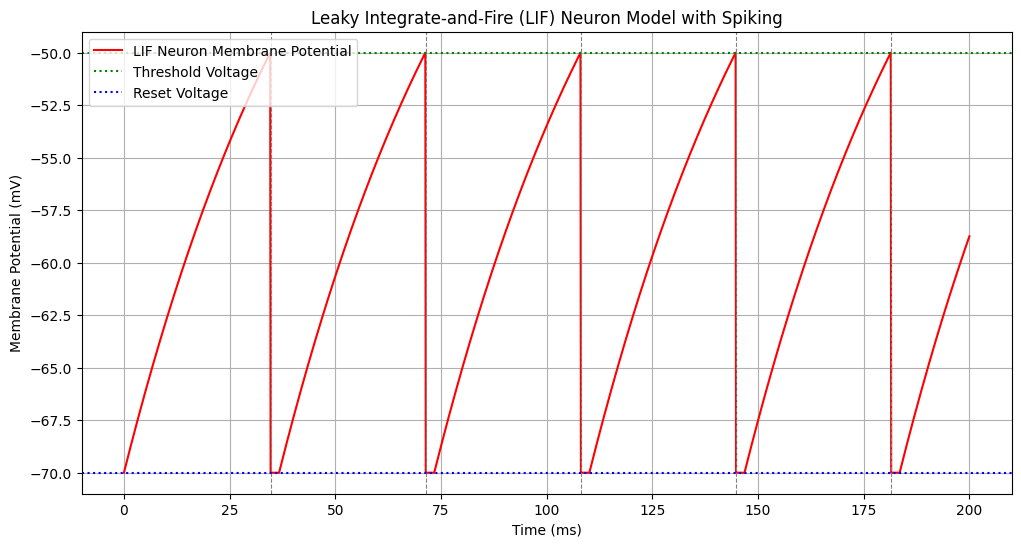

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, refractory_period_steps, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], *args)
            u[i+1] = u[i] + h * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 50.0     # Membrane time constant (ms)
R = 10.0     # Membrane resistance (MOhms)
I = 3.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)
refractory_period_steps = int(refractory_period / h_val)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(
    dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, refractory_period_steps, k, a, R, I
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

This is an example with "a" changed to 5 times it's value, meaning that the neuron takes 5 times the time to reach 1/e of it's starting value.

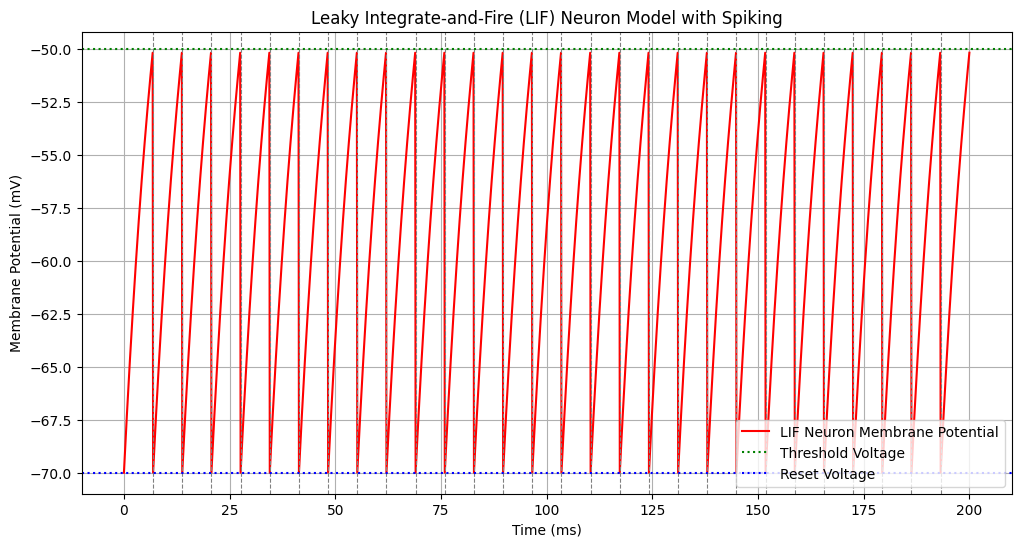

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start, t_end, h, u_threshold, u_reset, *args):
    t = np.arange(t_start, t_end + h, h) # Time points
    u = np.zeros(len(t)) # Array to store membrane potential values
    u[0] = u0 # Initial condition

    spike_times = []

    for i in range(0, len(t) - 1):
          # Integrate membrane potential
          du = dudt_func(u[i], t[i], *args)
          u[i+1] = u[i] + h * du

          # Check for spike
          if u[i+1] >= u_threshold:
              spike_times.append(t[i+1])
              u[i+1] = u_reset # Reset membrane potential after spike
    return t, u, spike_times

# Parameters for the LIF Neuron Model
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
h_val = 0.1    # Step size for Euler method (ms)
a = 10.0     # Membrane time constant (ms)
R = 10.0     # Membrane resistance (MOhms)
I = 3.0      # Injected current (nA) - Increased for spiking

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)

# Solve using Euler method with LIF spiking logic
t_euler, u_euler, spike_times = euler_method_lif(dudt, y0, t_start, t_end, h_val, u_threshold, u_reset, k, a, R, I)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler, u_euler, 'r-', label='LIF Neuron Membrane Potential')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

In this case, the Refractory period has been cut out of the model.

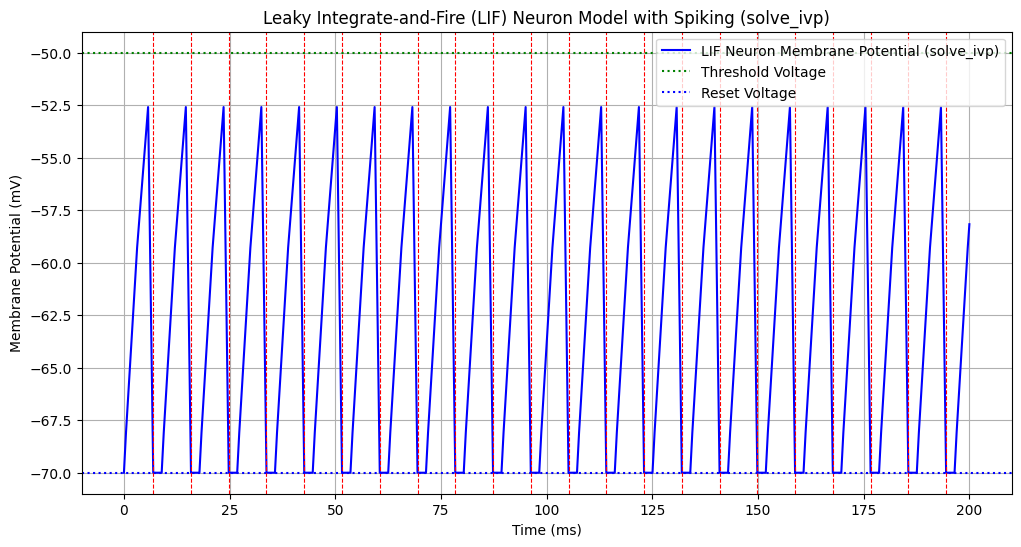

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the differential equation for the LIF neuron membrane potential
def dudt(t, u, k, a, R, I):
    # The equation is: a * (du/dt) = -(u - k) + R * I
    # So, du/dt = (-(u - k) + R * I) / a
    return (-(u - k) + R * I) / a

# Parameters for the LIF Neuron Model (same as before)
k = -60.0    # Membrane resting potential (mV)
y0 = -70.0   # Initial membrane potential (mV)
t_start = 0.0  # Start time (ms)
t_end = 200.0  # End time (ms)
a = 10.0     # Membrane time constant (ms)
R = 10.0     # Membrane resistance (MOhms)
I = 3.0      # Injected current (nA)

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)
refractory_period = 2.0 # Refractory period (ms)

# Event function for spike detection (when u crosses threshold)
def spike_event(t, u, k, a, R, I):
    return u[0] - u_threshold # Access the first element of u

# Stop integration when event occurs (spike_event returns 0)
spike_event.terminal = True
spike_event.direction = 1  # Only detect crossing from below to above

# List to store membrane potential and spike times
t_values = [t_start]
u_values = [y0]
spike_times = []

current_u = y0
current_t = t_start
refractory_active = False
refractory_end_time = 0.0

while current_t < t_end:
    if refractory_active:
        # During refractory period, set u to reset value and advance time
        if current_t + 0.1 <= refractory_end_time:
            t_values.append(current_t + 0.1)
            u_values.append(u_reset)
            current_t += 0.1
        else:
            # End of refractory period, jump to end time
            current_t = refractory_end_time
            u_values[-1] = u_reset # Ensure last point is at reset
            refractory_active = False
        continue

    # Solve until next event or end of simulation period
    sol = solve_ivp(dudt, [current_t, t_end], [current_u], args=(k, a, R, I),
                    events=spike_event, dense_output=True, rtol=1e-6, atol=1e-9)

    # Append results up to the event or end_time
    t_segment = sol.t
    u_segment = sol.y[0]

    # Handle initial condition already added
    if len(t_values) > 1 and t_segment[0] == t_values[-1]:
        t_segment = t_segment[1:]
        u_segment = u_segment[1:]

    t_values.extend(t_segment)
    u_values.extend(u_segment)

    # Update current time and potential
    current_t = t_values[-1]
    current_u = u_values[-1]

    # Check if a spike occurred
    if len(sol.t_events[0]) > 0:
        spike_time = sol.t_events[0][0]
        spike_times.append(spike_time)

        # Reset potential and start refractory period
        current_u = u_reset
        refractory_active = True
        refractory_end_time = current_t + refractory_period

        # Add a point at the spike time and reset potential if not already there
        if spike_time not in t_values:
            t_values.append(spike_time)
            u_values.append(u_threshold)
        # Ensure the next point after spike is at reset
        if len(t_values) > 0 and t_values[-1] < current_t:
            t_values.append(current_t)
            u_values.append(u_reset)
        elif len(t_values) > 0 and t_values[-1] == current_t:
             u_values[-1] = u_reset
    else:
        break # No more events, reached end_time

# Ensure time and potential arrays have the same length and are sorted
t_euler_ivp = np.array(t_values)
u_euler_ivp = np.array(u_values)

sort_indices = np.argsort(t_euler_ivp)
t_euler_ivp = t_euler_ivp[sort_indices]
u_euler_ivp = u_euler_ivp[sort_indices]

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_euler_ivp, u_euler_ivp, 'b-', label='LIF Neuron Membrane Potential (solve_ivp)')

# Plot spikes as vertical lines
for spike_time in spike_times:
    plt.axvline(spike_time, color='red', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title('Leaky Integrate-and-Fire (LIF) Neuron Model with Spiking (solve_ivp)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()